In [39]:
# step 1 import libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pandas.api.types import is_numeric_dtype
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [40]:
# step 2 load mobile dataset

file_path = Path("data/mobile-info.xlsx")
if not file_path.exists():
    raise FileNotFoundError("data/mobile-info.xlsx not found in experiment-11/data")

df = pd.read_excel(file_path)
df.columns = df.columns.str.strip().str.replace(" ", "_", regex=False)

df.shape, list(df.columns), df.head(5)

((491, 7),
 ['Product_Name',
  'Seller_Name',
  'Overall_Rating',
  'Overall_Review',
  'Seller_Rating',
  'Average_Rating',
  'Product_Quality'],
      Product_Name         Seller_Name  Overall_Rating  Overall_Review  Seller_Rating  Average_Rating Product_Quality
 0   RedmiNote6Pro   FlashstarCommerce          352708           32857            4.7             4.4       Excellent
 1   RedmiNote6Pro         SuperComNet          352708           32857            4.3             4.1       Excellent
 2      RedmiNote7         SuperComNet           10387            1057            4.3             4.6       Excellent
 3         RedmiY1        samaymobiles           17421            1634            3.1             3.7            Good
 4   RedmiNote6Pro   FlashstarCommerce           72964            7073            4.3             4.3       Excellent)

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product_Name     491 non-null    str    
 1   Seller_Name      491 non-null    str    
 2   Overall_Rating   491 non-null    int64  
 3   Overall_Review   491 non-null    int64  
 4   Seller_Rating    491 non-null    float64
 5   Average_Rating   491 non-null    float64
 6   Product_Quality  491 non-null    str    
dtypes: float64(2), int64(2), str(3)
memory usage: 27.0 KB
None


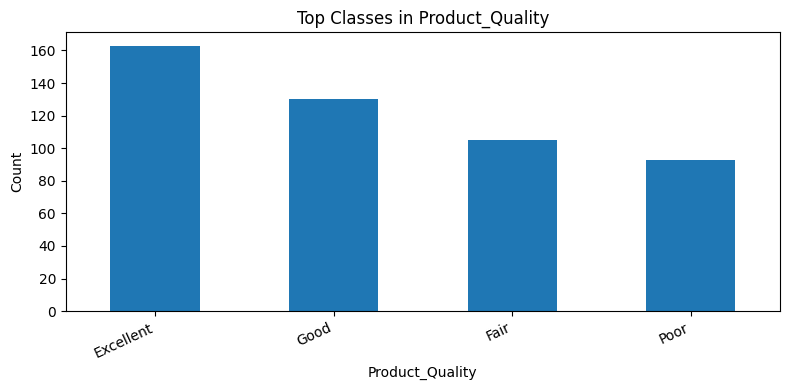

,Count
Product_Quality,
Excellent,163
Good,130
Fair,105
Poor,93


In [41]:
# step 3 inspect schema and target column

print(df.info())

schema = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Null Count": df.isna().sum().values,
    "Unique Values": df.nunique().values,
})

schema

# target variable for classification
if "Product_Quality" in df.columns:
    target_col = "Product_Quality"
else:
    target_col = df.columns[-1]

class_distribution = df[target_col].value_counts(dropna=False).sort_values(ascending=False).to_frame(name="Count")

plt.figure(figsize=(8, 4))
class_distribution.head(10).plot(kind="bar", legend=False, ax=plt.gca())
plt.title(f"Top Classes in {target_col}")
plt.ylabel("Count")
plt.xlabel(target_col)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

class_distribution

In [42]:
# step 4 clean data and encode categorical columns

df = df.drop_duplicates().copy()

# remove hidden non-breaking spaces that appear in some values
for column in df.columns:
    if not is_numeric_dtype(df[column]):
        df[column] = df[column].astype("string").str.replace("\xa0", " ", regex=False).str.strip()

encoders = {}

for column in df.columns:
    if is_numeric_dtype(df[column]):
        df[column] = df[column].fillna(df[column].median())
    else:
        # try numeric conversion for mixed text/number columns
        numeric_candidate = pd.to_numeric(df[column], errors="coerce")
        if numeric_candidate.notna().mean() >= 0.9:
            df[column] = numeric_candidate.fillna(numeric_candidate.median())
        else:
            mode_value = df[column].mode(dropna=True)
            fill_value = mode_value.iloc[0] if not mode_value.empty else "Unknown"
            df[column] = df[column].fillna(fill_value)
            encoder = LabelEncoder()
            df[column] = encoder.fit_transform(df[column].astype(str))
            encoders[column] = encoder

clean_summary = pd.DataFrame({
    "Metric": ["Rows after cleaning", "Columns", "Missing values", "Encoded columns"],
    "Value": [len(df), df.shape[1], int(df.isna().sum().sum()), len(encoders)],
})

clean_summary

df.head(5)

,Product_Name,Seller_Name,Overall_Rating,Overall_Review,Seller_Rating,Average_Rating,Product_Quality
0,12,1,352708,32857,4.7,4.4,0
1,12,13,352708,32857,4.3,4.1,0
2,13,13,10387,1057,4.3,4.6,0
3,14,21,17421,1634,3.1,3.7,2
4,12,1,72964,7073,4.3,4.3,0


In [43]:
# step 5 select features and split into training and testing sets

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y if y.nunique() > 1 else None,
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Target classes:", y.nunique())

Training shape: (158, 6)
Testing shape: (68, 6)
Target classes: 4


Decision Tree Classifier
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
confusion matrix
[[28  0  0  0]
 [ 0  9  0  0]
 [ 0  0 22  0]
 [ 0  0  0  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00         9

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



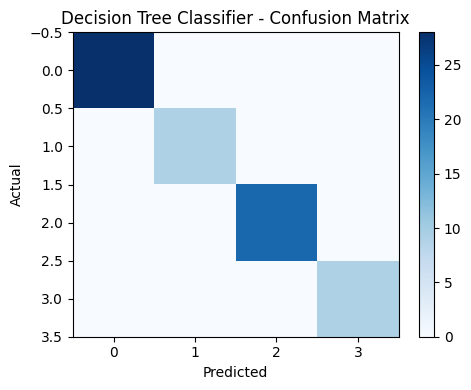

In [44]:
# step 6 define evaluation helper and train decision tree classifier

def evaluate_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    print(model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("confusion matrix")
    print(cm)
    print(report)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues", aspect="auto")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm,
        "classification_report": report,
    }


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
decision_tree_results = evaluate_model(dt_model, X_test, y_test, "Decision Tree Classifier")

Random Forest Classifier
Accuracy: 0.9264705882352942
Precision: 0.9290441176470587
Recall: 0.9264705882352942
F1 Score: 0.9271079949007467
confusion matrix
[[28  0  0  0]
 [ 0  7  1  1]
 [ 0  1 21  0]
 [ 0  2  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.70      0.78      0.74         9
           2       0.95      0.95      0.95        22
           3       0.88      0.78      0.82         9

    accuracy                           0.93        68
   macro avg       0.88      0.88      0.88        68
weighted avg       0.93      0.93      0.93        68



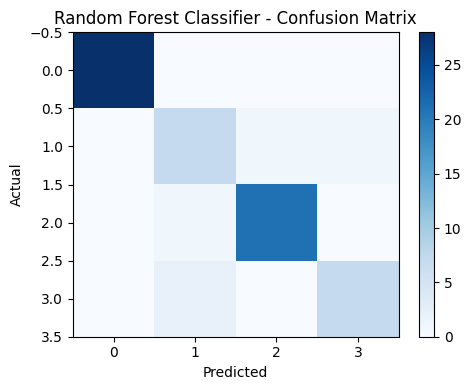

In [45]:
# step 7 train random forest classifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
random_forest_results = evaluate_model(rf_model, X_test, y_test, "Random Forest Classifier")

Support Vector Machine Classifier
Accuracy: 0.8823529411764706
Precision: 0.8941628959276017
Recall: 0.8823529411764706
F1 Score: 0.8847413549215469
confusion matrix
[[24  0  4  0]
 [ 0  8  1  0]
 [ 1  1 20  0]
 [ 0  0  1  8]]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        28
           1       0.89      0.89      0.89         9
           2       0.77      0.91      0.83        22
           3       1.00      0.89      0.94         9

    accuracy                           0.88        68
   macro avg       0.90      0.89      0.89        68
weighted avg       0.89      0.88      0.88        68



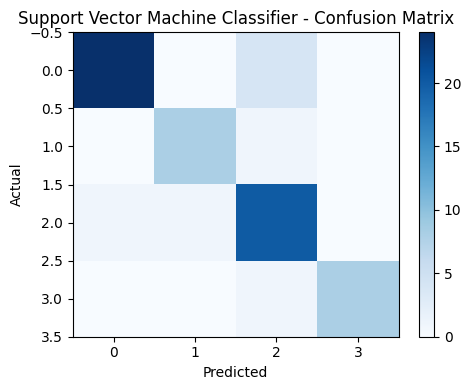

In [46]:
# step 8 train support vector machine classifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="rbf", gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_results = evaluate_model(svm_model, X_test_scaled, y_test, "Support Vector Machine Classifier")

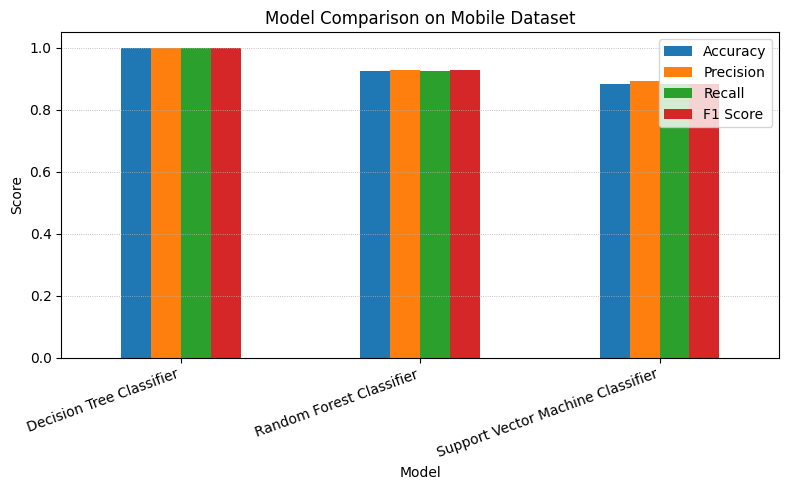

Best model: Decision Tree Classifier
Best accuracy: 1.0
Best F1 score: 1.0


In [47]:
# step 9 compare all models with common metrics

comparison_df = pd.DataFrame([
    {
        "Model": decision_tree_results["model_name"],
        "Accuracy": decision_tree_results["accuracy"],
        "Precision": decision_tree_results["precision"],
        "Recall": decision_tree_results["recall"],
        "F1 Score": decision_tree_results["f1_score"],
    },
    {
        "Model": random_forest_results["model_name"],
        "Accuracy": random_forest_results["accuracy"],
        "Precision": random_forest_results["precision"],
        "Recall": random_forest_results["recall"],
        "F1 Score": random_forest_results["f1_score"],
    },
    {
        "Model": svm_results["model_name"],
        "Accuracy": svm_results["accuracy"],
        "Precision": svm_results["precision"],
        "Recall": svm_results["recall"],
        "F1 Score": svm_results["f1_score"],
    },
])

comparison_df = comparison_df.sort_values(["Accuracy", "F1 Score"], ascending=False).reset_index(drop=True)
comparison_df

plt.figure(figsize=(8, 5))
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", ax=plt.gca())
plt.title("Model Comparison on Mobile Dataset")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle=":", linewidth=0.6)
plt.tight_layout()
plt.show()

best_model = comparison_df.iloc[0]
print("Best model:", best_model["Model"])
print("Best accuracy:", best_model["Accuracy"])
print("Best F1 score:", best_model["F1 Score"])

In [48]:
# step 10 prediction demo and output validation

validation_results = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Decision Tree": decision_tree_results["y_pred"],
    "Random Forest": random_forest_results["y_pred"],
    "SVM": svm_results["y_pred"],
})

validation_results.head(10)

,Actual,Decision Tree,Random Forest,SVM
0,1,1,1,1
1,1,1,2,1
2,2,2,2,2
3,0,0,0,0
4,3,3,3,3
5,0,0,0,0
6,2,2,2,2
7,2,2,2,2
8,0,0,0,2
9,0,0,0,0


In [49]:
# step 11 final output tables in notebook

print("Model comparison table")
comparison_df

print("Prediction validation table (first 20 rows)")
validation_results.head(20)

Model comparison table
Prediction validation table (first 20 rows)


,Actual,Decision Tree,Random Forest,SVM
0,1,1,1,1
1,1,1,2,1
2,2,2,2,2
3,0,0,0,0
4,3,3,3,3
5,0,0,0,0
6,2,2,2,2
7,2,2,2,2
8,0,0,0,2
9,0,0,0,0
